In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../Data/cleaned/cleaned_online_retail.csv")

In [3]:
df

,Unnamed: 0,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12.0,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.40
1,1,489434,79323P,PINK CHERRY LIGHTS,12.0,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00
2,2,489434,79323W,WHITE CHERRY LIGHTS,12.0,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00
3,3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",27.0,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.80
4,4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24.0,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.00
...,...,...,...,...,...,...,...,...,...,...
779420,1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6.0,2011-12-09 12:50:00,2.10,12680,France,12.60
779421,1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4.0,2011-12-09 12:50:00,4.15,12680,France,16.60
779422,1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4.0,2011-12-09 12:50:00,4.15,12680,France,16.60
779423,1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3.0,2011-12-09 12:50:00,4.95,12680,France,14.85


In [4]:
df.head()

,Unnamed: 0,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12.0,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,1,489434,79323P,PINK CHERRY LIGHTS,12.0,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,2,489434,79323W,WHITE CHERRY LIGHTS,12.0,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",27.0,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24.0,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


In [5]:
df.shape

(779425, 10)

In [6]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 779425 entries, 0 to 779424
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Unnamed: 0   779425 non-null  int64         
 1   Invoice      779425 non-null  int64         
 2   StockCode    779425 non-null  object        
 3   Description  779425 non-null  object        
 4   Quantity     779425 non-null  float64       
 5   InvoiceDate  779425 non-null  datetime64[ns]
 6   Price        779425 non-null  float64       
 7   Customer ID  779425 non-null  int64         
 8   Country      779425 non-null  object        
 9   Revenue      779425 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(3), object(3)
memory usage: 59.5+ MB


In [8]:
df.tail()

,Unnamed: 0,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
779420,1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6.0,2011-12-09 12:50:00,2.10,12680,France,12.60
779421,1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4.0,2011-12-09 12:50:00,4.15,12680,France,16.60
779422,1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4.0,2011-12-09 12:50:00,4.15,12680,France,16.60
779423,1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3.0,2011-12-09 12:50:00,4.95,12680,France,14.85
779424,1067370,581587,POST,POSTAGE,1.0,2011-12-09 12:50:00,18.00,12680,France,18.00


In [9]:
daily_revenue = df.groupby(df['InvoiceDate'].dt.date)["Revenue"].sum()

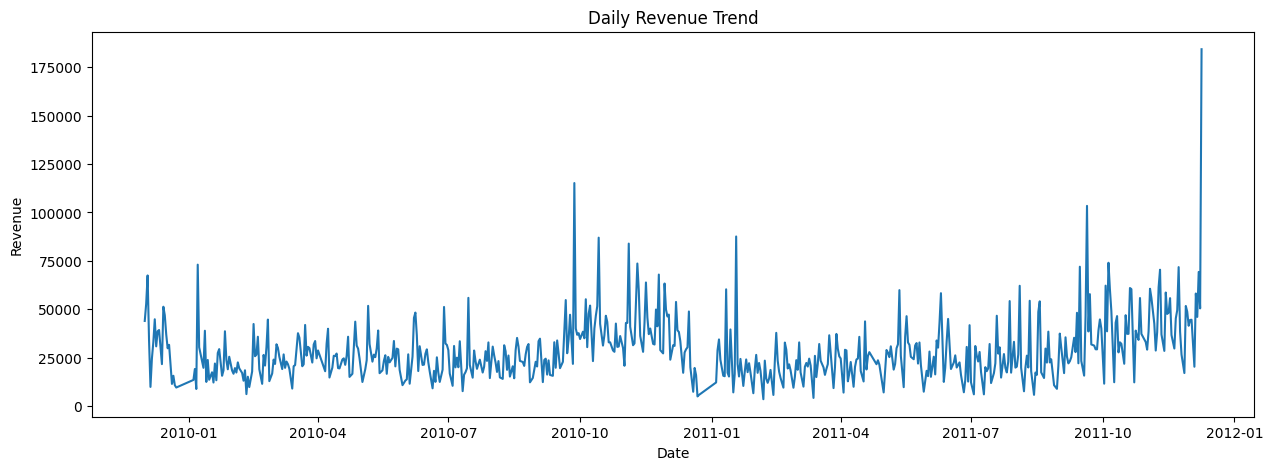

In [10]:
plt.figure(figsize = (15,5))
daily_revenue.plot()
plt.title("Daily Revenue Trend")

plt.xlabel("Date")

plt.ylabel("Revenue")

plt.show()

# Should Observe
    * upward trends
    * weekly patterns
    * abnormal spikes
    * seasonal behavior

## These observations will later help:

    * Prophet
    * LSTM
    * inventory forecasting

In [11]:
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

In [12]:
monthly_sales = df.groupby(
    'YearMonth'
)['Revenue'].sum()

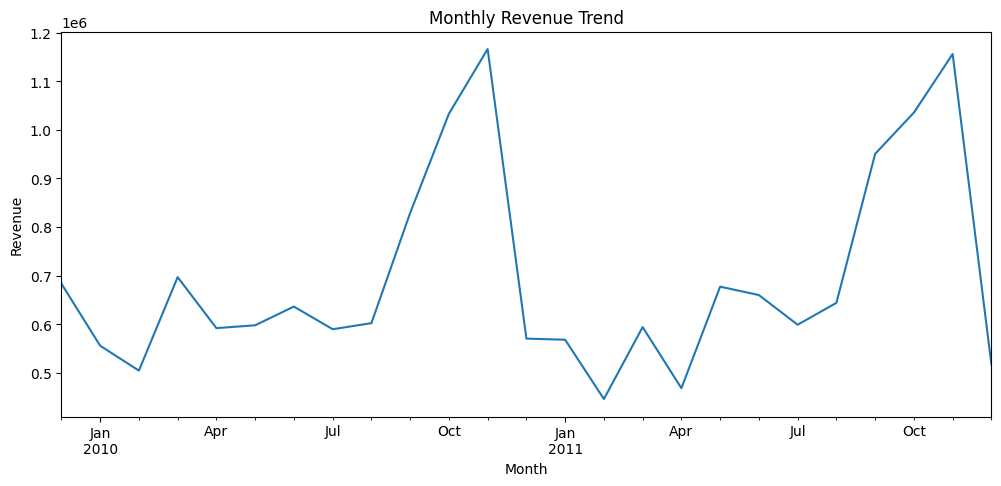

In [13]:
plt.figure(figsize=(12,5))

monthly_sales.plot()

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.show()

## This helps detect:

* seasonality
* business cycles
* festive peaks
* trend shifts

## Critical for:

* demand forecasting
* inventory planning

In [14]:
top_products = df.groupby(
    'Description'
)['Quantity'].sum().sort_values(
    ascending=False
).head(10)

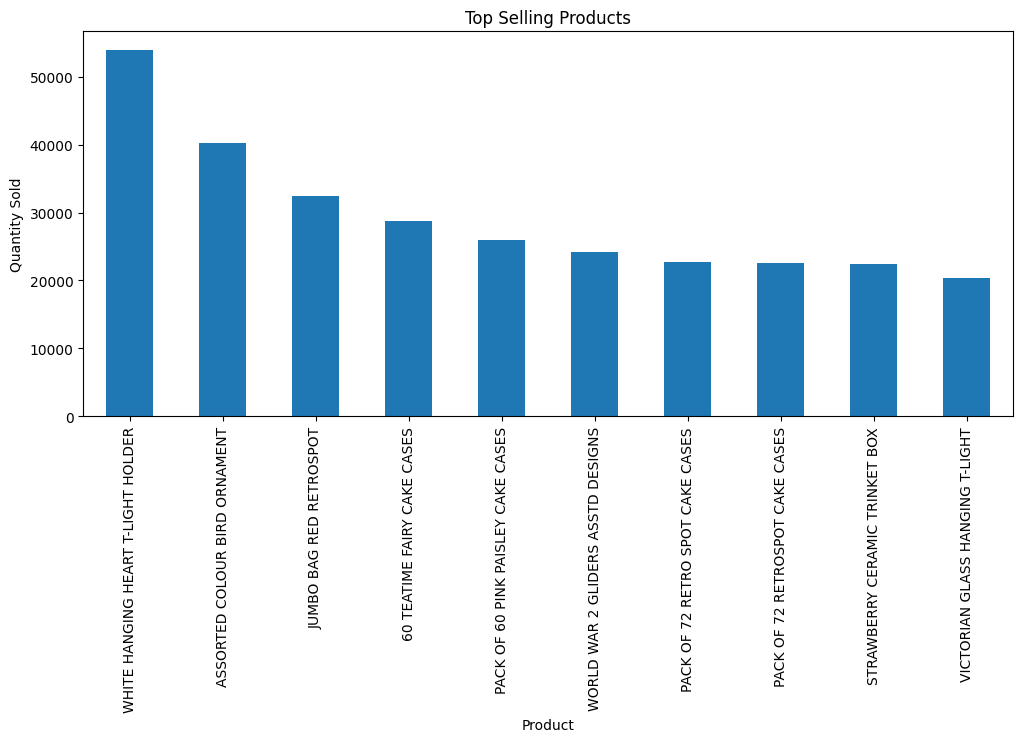

In [15]:
plt.figure(figsize=(12,5))

top_products.plot(kind='bar')

plt.title("Top Selling Products")

plt.xlabel("Product")

plt.ylabel("Quantity Sold")

plt.show()

## This identifies:

* fast-moving products
* high-demand SKUs
* inventory priorities

## Useful for:

* ABC analysis
* forecasting
* reorder optimization

In [16]:
country_sales = df.groupby(
    'Country'
)['Revenue'].sum().sort_values(
    ascending=False
)
country_sales.head(10)

Country
United Kingdom    1.438923e+07
EIRE              6.165705e+05
Netherlands       5.540381e+05
Germany           4.250197e+05
France            3.487690e+05
Australia         1.692835e+05
Spain             1.083325e+05
Switzerland       1.000619e+05
Sweden            9.151582e+04
Denmark           6.858069e+04
Name: Revenue, dtype: float64

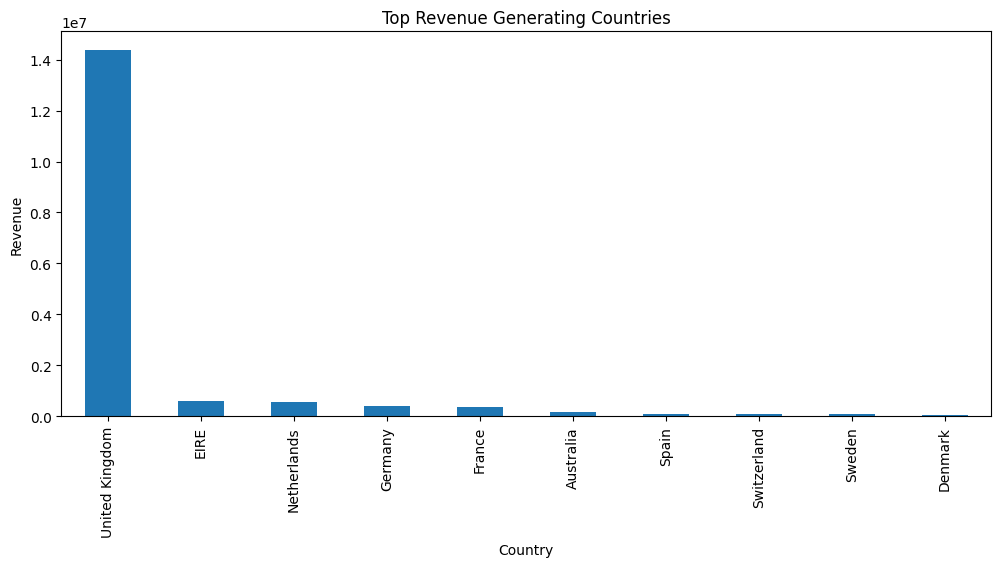

In [17]:
plt.figure(figsize=(12,5))

country_sales.head(10).plot(
    kind='bar'
)

plt.title("Top Revenue Generating Countries")

plt.ylabel("Revenue")

plt.show()

# RFM Analysis
* recency
* frequency
* monetary

In [18]:
snapshot_date = df['InvoiceDate'].max()

In [19]:
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x:
        (snapshot_date - x.max()).days,

    'Invoice': 'nunique',

    'Revenue': 'sum'
})

In [20]:
rfm.columns = [
    'Recency',
    'Frequency',
    'Monetary'
]

In [21]:
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346,325,12,77556.46
12347,1,8,4921.53
12348,74,5,2019.40
12349,18,4,4428.69
12350,309,1,334.40


## RFM directly supports:

* churn prediction
* segmentation
* customer intelligence
* personalized marketing

In [22]:
daily_sales = df.groupby(
    ['InvoiceDate','StockCode']
)['Quantity'].sum().reset_index()

In [23]:
daily_sales

,InvoiceDate,StockCode,Quantity
0,2009-12-01 07:45:00,21232,24.0
1,2009-12-01 07:45:00,21523,10.0
2,2009-12-01 07:45:00,21871,24.0
3,2009-12-01 07:45:00,22041,27.0
4,2009-12-01 07:45:00,22064,24.0
...,...,...,...
767412,2011-12-09 12:50:00,22899,6.0
767413,2011-12-09 12:50:00,23254,4.0
767414,2011-12-09 12:50:00,23255,4.0
767415,2011-12-09 12:50:00,23256,4.0


In [24]:
daily_sales['Lag1'] = daily_sales.groupby(
    'StockCode'
)['Quantity'].shift(1)

In [25]:
daily_sales['Lag7'] = daily_sales.groupby(
    'StockCode'
)['Quantity'].shift(7)

In [26]:
daily_sales['RollingMean7'] = (
    daily_sales.groupby('StockCode')
    ['Quantity']
    .transform(
        lambda x:
        x.rolling(
            7,
            min_periods=1
        ).mean()
    )
)

In [27]:
daily_sales['Day'] = daily_sales[
    'InvoiceDate'
].dt.day

daily_sales['Month'] = daily_sales[
    'InvoiceDate'
].dt.month

daily_sales['Weekday'] = daily_sales[
    'InvoiceDate'
].dt.weekday

daily_sales['Quarter'] = daily_sales[
    'InvoiceDate'
].dt.quarter

In [28]:
daily_sales.isnull().sum()

InvoiceDate         0
StockCode           0
Quantity            0
Lag1             4631
Lag7            30342
RollingMean7        0
Day                 0
Month               0
Weekday             0
Quarter             0
dtype: int64

In [29]:
daily_sales.fillna(0, inplace=True)

In [30]:
daily_sales.to_csv(
    "../Data/processed/daily_sales_features.csv"
)

In [31]:
rfm.to_csv(
    "../Data/processed/rfm_features.csv"
)

In [32]:
Achieve Today

By end of Day 3:

1. Business Intelligence
revenue trends
top products
geography analysis
2. Customer Intelligence
RFM dataset
customer behavior metrics
3. Forecasting Features
lag features
rolling statistics
date features
4. Feature-Ready Datasets

Needed for:

Prophet
LSTM
churn models
segmentation
inventory optimization

SyntaxError: invalid syntax (2016266090.py, line 1)